# Installation

In [2]:
#!pip install pandas matplotlib jiwer

In [26]:
import os
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from jiwer import (
    wer,
    cer,
    process_words,
    process_characters
)

In [27]:
pages = [8, 9, 12, 38, 53, 78, 94, 105, 114, 115,
        210, 314, 316, 384, 457, 468, 490, 619, 615, 753]

In [28]:
output_dir = "All_Results"

os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: All_Results


In [29]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [30]:
def calculate_metrics(gold_text, pred_text):
    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    word_result = process_words(
        gold_norm,
        pred_norm
    )

    character_result = process_characters(
        gold_norm,
        pred_norm
    )

    gold_word_count = len(gold_norm.split())
    gold_character_count = len(gold_norm)

    word_hallucination_rate = (
        word_result.insertions / gold_word_count
        if gold_word_count > 0
        else 0
    )

    character_hallucination_rate = (
        character_result.insertions / gold_character_count
        if gold_character_count > 0
        else 0
    )

    return {
        "WER": wer_score,
        "CER": cer_score,
        "Word_Insertions": word_result.insertions,
        "Character_Insertions": character_result.insertions,
        "Word_Hallucination_Rate": word_hallucination_rate,
        "Character_Hallucination_Rate": character_hallucination_rate
    }

In [31]:
model_dirs_exp1 = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_1",
    #"Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_1",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_1",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_1"
}

In [32]:
for model, model_dir in model_dirs_exp1.items():
    print(
        model,
        "->",
        model_dir,
        "| Exists:",
        os.path.isdir(model_dir)
    )

GPT-5.4 -> GPT_5.4/outputs/Experiment_1 | Exists: True
Qwen3.5-35B-A3B -> Qwen 3.5_35B_A3B/outputs/Experiment_1 | Exists: True
PaddleOCR-VL 1.5 -> PaddleOCR-VL_1.5/outputs/Experiment_1 | Exists: True


In [53]:
results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs_exp1.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        metrics = calculate_metrics(
            gold_text,
            pred_text
        )

        results_exp1.append({
            "Model": model,
            "Page": p,
            **metrics
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating PaddleOCR-VL 1.5...
Evaluating p

In [54]:
df_exp1 = pd.DataFrame(results_exp1)

#df_exp1.head()

# Experiment 1

In [55]:
df_exp1_display = df_exp1.copy()

df_exp1_display["WER"] *= 100
df_exp1_display["CER"] *= 100
df_exp1_display["Word_Hallucination_Rate"] *= 100
df_exp1_display["Character_Hallucination_Rate"] *= 100

#df_exp1_display

## GPT 

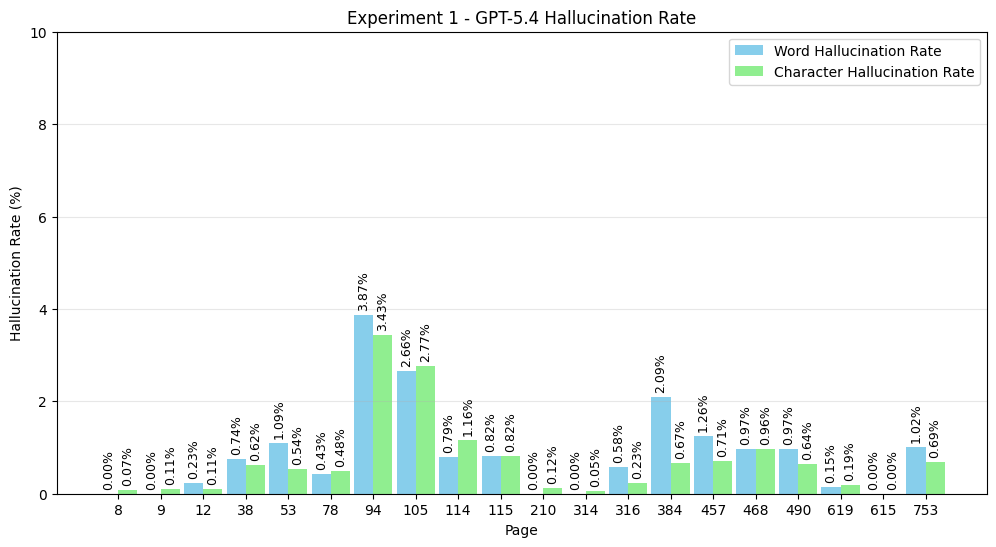

In [56]:
df_model = df_exp1[
    df_exp1["Model"] == "GPT-5.4"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 1 - GPT-5.4 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)

plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))
plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_gpt_5_4_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

In [ ]:
"""# With vector graphics

df_model = df_exp1[
    df_exp1["Model"] == "Gemini 3.1 Pro"
].copy()

x = np.arange(len(df_model))
width = 0.45

wer_pct = df_model["WER"] * 100
cer_pct = df_model["CER"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    wer_pct,
    width,
    label="WER",
    color="#6AAA00"
)

bars2 = plt.bar(
    x + width / 2,
    cer_pct,
    width,
    label="CER",
    color="#808080"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 10))

os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_gemini_3_1.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Qwen

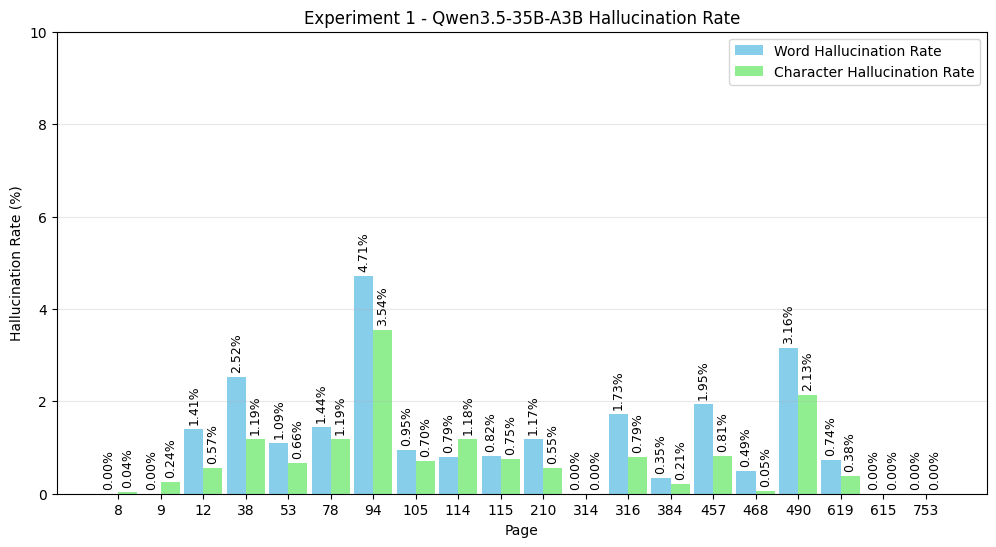

In [58]:
df_model = df_exp1[
    df_exp1["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 1 - Qwen3.5-35B-A3B Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)

plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_qwen_3_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR-VL

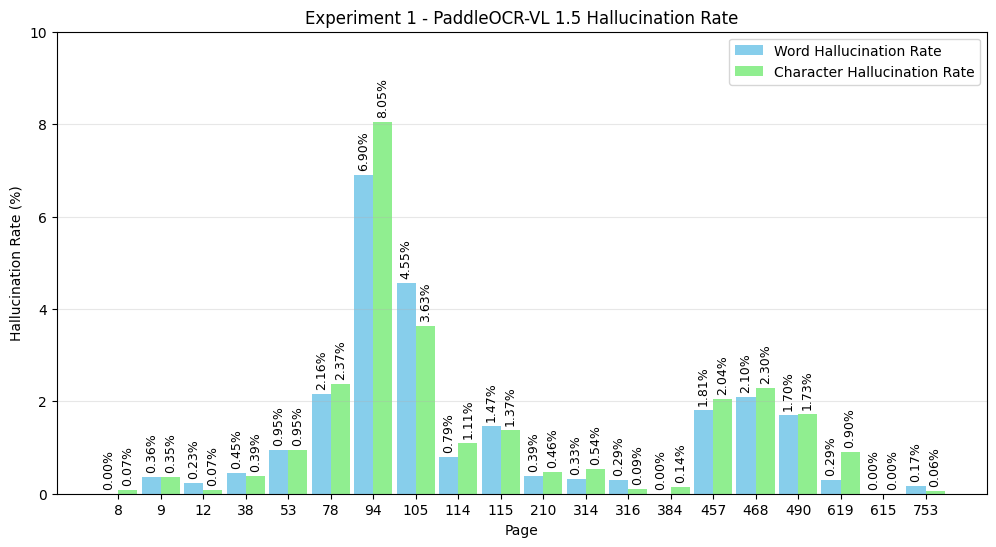

In [59]:
df_model = df_exp1[
    df_exp1["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 1 - PaddleOCR-VL 1.5 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)

plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_1_paddleocr_vl_1_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Experiment 2

In [21]:
model_dirs_exp2 = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_2",
    #"Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_2",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_2",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_2"
}

In [22]:
results_exp2 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs_exp2.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        metrics = calculate_metrics(
            gold_text,
            pred_text
        )

        results_exp2.append({
            "Model": model,
            "Page": p,
            **metrics
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating PaddleOCR-VL 1.5...
Evaluating p

In [23]:
df_exp2 = pd.DataFrame(results_exp2)

df_exp2_display = df_exp2.copy()

df_exp2_display["WER"] *= 100
df_exp2_display["CER"] *= 100
df_exp2_display["Word_Hallucination_Rate"] *= 100
df_exp2_display["Character_Hallucination_Rate"] *= 100

#df_exp2_display

## GPT

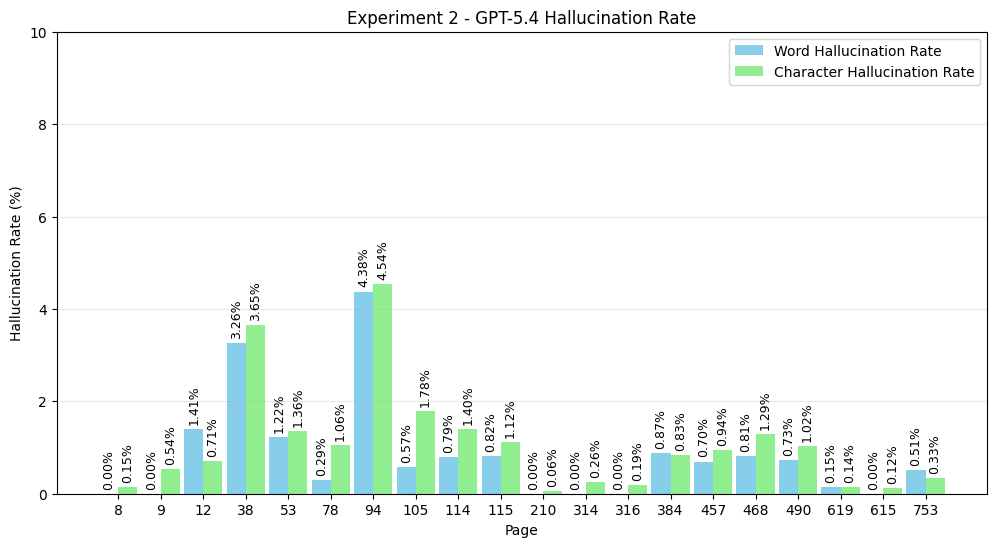

In [25]:
df_model = df_exp2[
    df_exp2["Model"] == "GPT-5.4"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 2 - GPT-5.4 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_gpt_5_4_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

In [42]:
"""df_model = df_exp2[
    df_exp2["Model"] == "Gemini"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 2 - GPT-5.4 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_gpt_5_4_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()"""

'df_model = df_exp2[\n    df_exp2["Model"] == "Gemini"\n].copy()\n\nx = np.arange(len(df_model))\nwidth = 0.45\n\nword_hallucination_pct = (\n    df_model["Word_Hallucination_Rate"] * 100\n)\n\ncharacter_hallucination_pct = (\n    df_model["Character_Hallucination_Rate"] * 100\n)\n\nplt.figure(figsize=(12, 6))\n\nbars1 = plt.bar(\n    x - width / 2,\n    word_hallucination_pct,\n    width,\n    label="Word Hallucination Rate",\n    color="skyblue"\n)\n\nbars2 = plt.bar(\n    x + width / 2,\n    character_hallucination_pct,\n    width,\n    label="Character Hallucination Rate",\n    color="lightgreen"\n)\n\nfor bar in bars1:\n    plt.text(\n        bar.get_x() + bar.get_width() / 2,\n        bar.get_height() + 0.1,\n        f"{bar.get_height():.2f}%",\n        ha="center",\n        va="bottom",\n        rotation=90,\n        fontsize=9\n    )\n\nfor bar in bars2:\n    plt.text(\n        bar.get_x() + bar.get_width() / 2,\n        bar.get_height() + 0.1,\n        f"{bar.get_height():.2f}

## Qwen

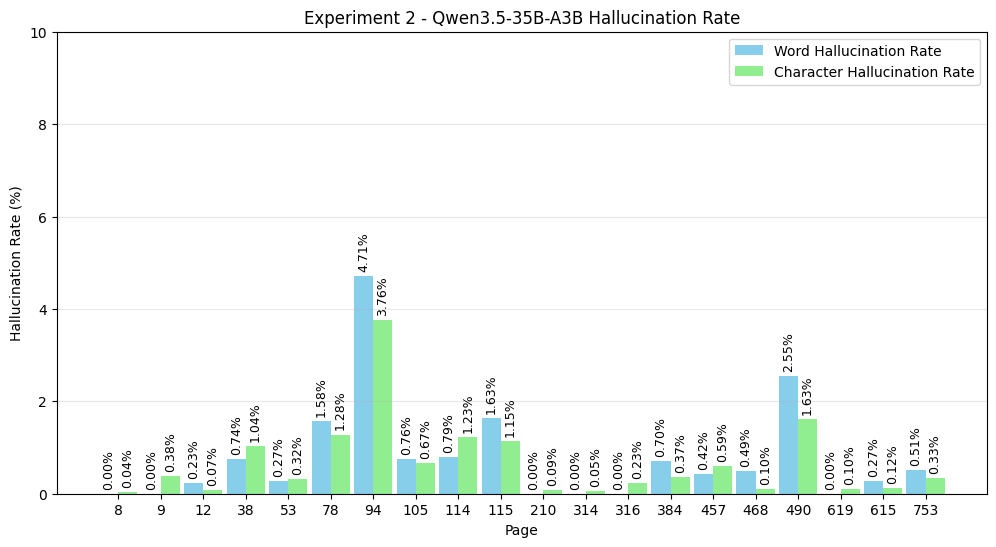

In [43]:
df_model = df_exp2[
    df_exp2["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 2 - Qwen3.5-35B-A3B Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_qwen_3_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR-VL

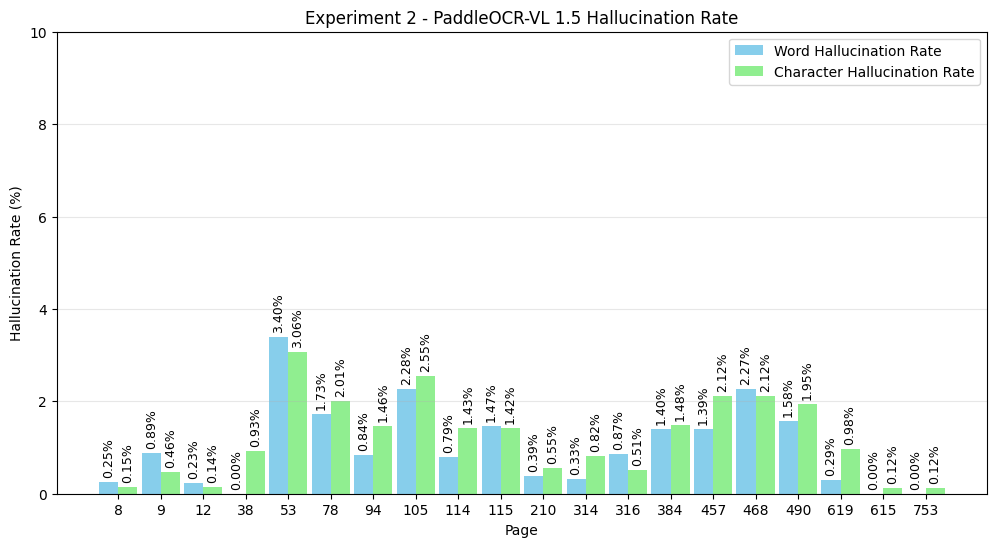

In [44]:
df_model = df_exp2[
    df_exp2["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 2 - PaddleOCR-VL 1.5 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_2_PaddleOCR-VL_1_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

# Experiment 3

In [45]:
model_dirs_exp3 = {
    "GPT-5.4": "GPT_5.4/outputs/Experiment_3",
    #"Gemini 3.1 Pro": "Gemini_3.1_Pro/outputs/Experiment_3",
    "Qwen3.5-35B-A3B": "Qwen 3.5_35B_A3B/outputs/Experiment_3",
    "PaddleOCR-VL 1.5": "PaddleOCR-VL_1.5/outputs/Experiment_3"
}

In [46]:
results_exp3 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for model, model_dir in model_dirs_exp3.items():

    print(f"\nEvaluating {model}...")

    for p in pages:
        print(f"Evaluating page {p}...")

        gold_url = f"{gold_base}{p}.txt"
        gold_text = requests.get(gold_url).text

        pred_path = os.path.join(
            model_dir,
            f"page_{p}.txt"
        )

        with open(
            pred_path,
            "r",
            encoding="utf-8"
        ) as f:
            pred_text = f.read()

        metrics = calculate_metrics(
            gold_text,
            pred_text
        )

        results_exp3.append({
            "Model": model,
            "Page": p,
            **metrics
        })


Evaluating GPT-5.4...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating Qwen3.5-35B-A3B...
Evaluating page 8...
Evaluating page 9...
Evaluating page 12...
Evaluating page 38...
Evaluating page 53...
Evaluating page 78...
Evaluating page 94...
Evaluating page 105...
Evaluating page 114...
Evaluating page 115...
Evaluating page 210...
Evaluating page 314...
Evaluating page 316...
Evaluating page 384...
Evaluating page 457...
Evaluating page 468...
Evaluating page 490...
Evaluating page 619...
Evaluating page 615...
Evaluating page 753...

Evaluating PaddleOCR-VL 1.5...
Evaluating p

In [48]:
df_exp3 = pd.DataFrame(results_exp3)

df_exp3_display = df_exp3.copy()

df_exp3_display["WER"] *= 100
df_exp3_display["CER"] *= 100
df_exp3_display["Word_Hallucination_Rate"] *= 100
df_exp3_display["Character_Hallucination_Rate"] *= 100

#df_exp3_display

## GPT

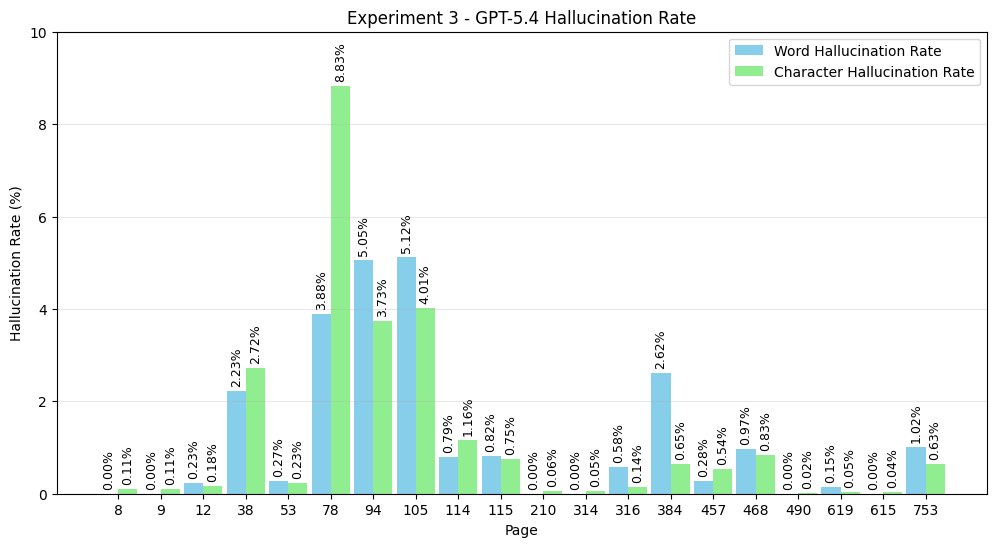

In [49]:
df_model = df_exp3[
    df_exp3["Model"] == "GPT-5.4"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 3 - GPT-5.4 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_gpt_5_4_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Gemini

## Qwen

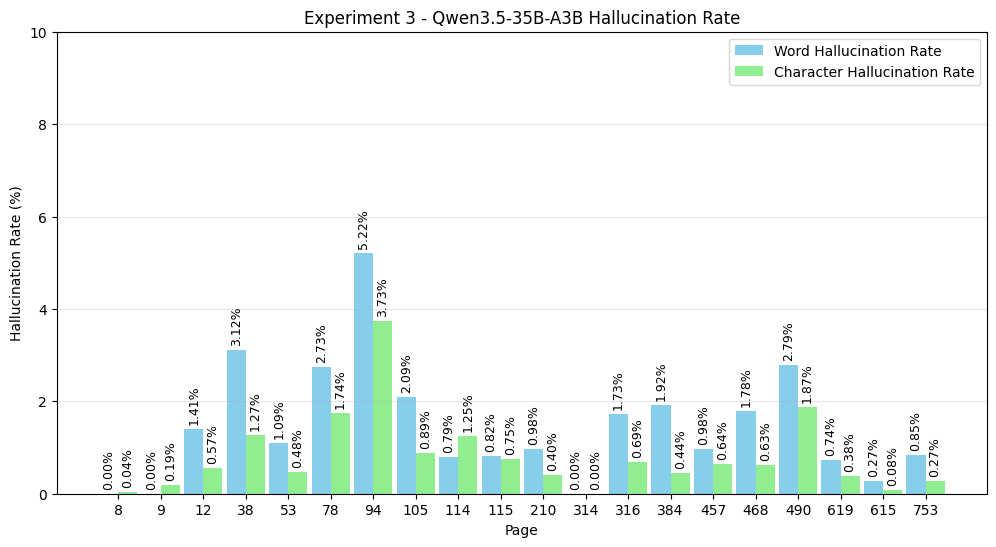

In [50]:
df_model = df_exp3[
    df_exp3["Model"] == "Qwen3.5-35B-A3B"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 3 - Qwen3.5-35B-A3B Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_qwen_3_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## PaddleOCR - VL

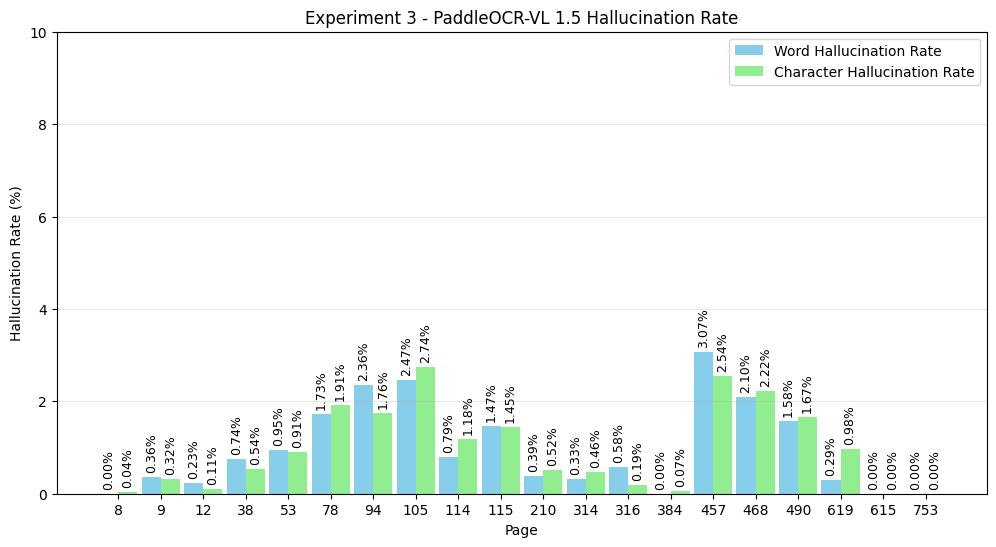

In [51]:
df_model = df_exp3[
    df_exp3["Model"] == "PaddleOCR-VL 1.5"
].copy()

x = np.arange(len(df_model))
width = 0.45

word_hallucination_pct = (
    df_model["Word_Hallucination_Rate"] * 100
)

character_hallucination_pct = (
    df_model["Character_Hallucination_Rate"] * 100
)

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width / 2,
    word_hallucination_pct,
    width,
    label="Word Hallucination Rate",
    color="skyblue"
)

bars2 = plt.bar(
    x + width / 2,
    character_hallucination_pct,
    width,
    label="Character Hallucination Rate",
    color="lightgreen"
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_model["Page"])
plt.xlabel("Page")
plt.ylabel("Hallucination Rate (%)")
plt.title("Experiment 3 - PaddleOCR-VL 1.5 Hallucination Rate")

plt.legend()
plt.grid(axis="y", alpha=0.3)

max_value = max(
    word_hallucination_pct.max(),
    character_hallucination_pct.max()
)
plt.ylim(0, 10)
plt.yticks(np.arange(0, 11, 2))

plt.savefig(
    os.path.join(
        output_dir,
        "experiment_3_PaddleOCR-VL_1_5_hallucination_rate.pdf"
    ),
    bbox_inches="tight"
)

plt.show()